In [1]:
print("Yes")

Yes


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def fetch_and_prepare_data():
    # fetching data from the UCL repository
    url= "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
    try:
        df=pd.read_excel(url)
        print(f"{len(df)} transactions.")
    except Exception as e:
        print(f"Error: {e}")
        return None

    df = df.dropna(subset=["StockCode", "Description", 'Quantity'])
    df= df[df["Quantity"]>0]
    df["InvoiceDate"]= pd.to_datetime(df["InvoiceDate"])


    # Transforming into an FMCG Simulation

    top_products=df["StockCode"].value_counts().index
    target_sku=top_products[0] # frequent item 

    product_df= df[df["StockCode"]== target_sku].copy()
    daily_sales=product_df.groupby([product_df["InvoiceDate"].dt.date, "Country"])["Quantity"].sum().reset_index()
    daily_sales.columns=["Date", "Region", "Units_Sold"]
    daily_sales["Date"]=pd.to_datetime(daily_sales["Date"])

    

    # Data sorting
    daily_sales= daily_sales.sort_values(by=["Region","Date"]).reset_index(drop=True)

    # Base assumption is that the region baseline stock capacity of 1000 and try to track sales deplete that the stock over time

    capacity=1000
    reorder_threshold=200

    simulated_records = []

    for region, group in daily_sales.groupby("Region"):
        current_stock=capacity
        for idx, row in group.iterrows():
            units_sold=row["Units_Sold"]
            current_stock -= units_sold

            if current_stock < 0:
                current_stock=0

            reorder_triggered = 1 if current_stock <= reorder_threshold else 0

            simulated_records.append({
                "Date": row["Date"],
                "Region": region,
                "Units_Sold": units_sold,
                "Current_Stock": current_stock,
                "Reorder_Triggered": reorder_triggered
            })

            if reorder_triggered == 1:
                current_stock = capacity

    sandbox_fmcg_df = pd.DataFrame(simulated_records)

    print(f" Engineered {len(sandbox_fmcg_df)} clean history")
    return sandbox_fmcg_df
if __name__ == "__main__":
    fmcg_data= fetch_and_prepare_data()

    if fmcg_data is not None:
        print(f"Processed Supply Chain Features {fmcg_data.head(15)}")

        fmcg_data.to_csv(r"Sandbox_fmcg_pipeline.csv", index=False)
        print("Saved the data ")

541909 transactions.
 Engineered 396 clean history
Processed Supply Chain Features          Date           Region  Units_Sold  Current_Stock  Reorder_Triggered
0  2011-01-20        Australia           6            994                  0
1  2011-03-10  Channel Islands          12            988                  0
2  2011-08-01  Channel Islands          12            976                  0
3  2011-10-14  Channel Islands          72            904                  0
4  2011-11-06  Channel Islands          12            892                  0
5  2010-12-14           Cyprus          64            936                  0
6  2011-02-07           Cyprus           8            928                  0
7  2011-02-16           Cyprus          32            896                  0
8  2011-10-19           Cyprus          30            866                  0
9  2011-11-18           Cyprus          10            856                  0
10 2010-12-16             EIRE          24            976             

### EDA

In [16]:
df_raw=pd.read_excel("https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx")

In [22]:
df_raw.info()
df_raw.describe()

print("Missing Values: ",df_raw.isnull().sum())

negative_quantities = df_raw[df_raw['Quantity'] < 0]
print(f"Number of cancelled/returned transactions: {len(negative_quantities)}")

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   DateOnly     541909 non-null  object        
dtypes: datetime64[us](1), float64(2), int64(1), object(4), str(1)
memory usage: 37.2+ MB
Missing Values:  InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
DateOnly            0
dtype: int64
Number of cancelled/returned tran

C:\Users\Admin\AppData\Local\Temp\ipykernel_10360\1360911003.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.index.astype(str), y=top_items.values,palette="viridis")


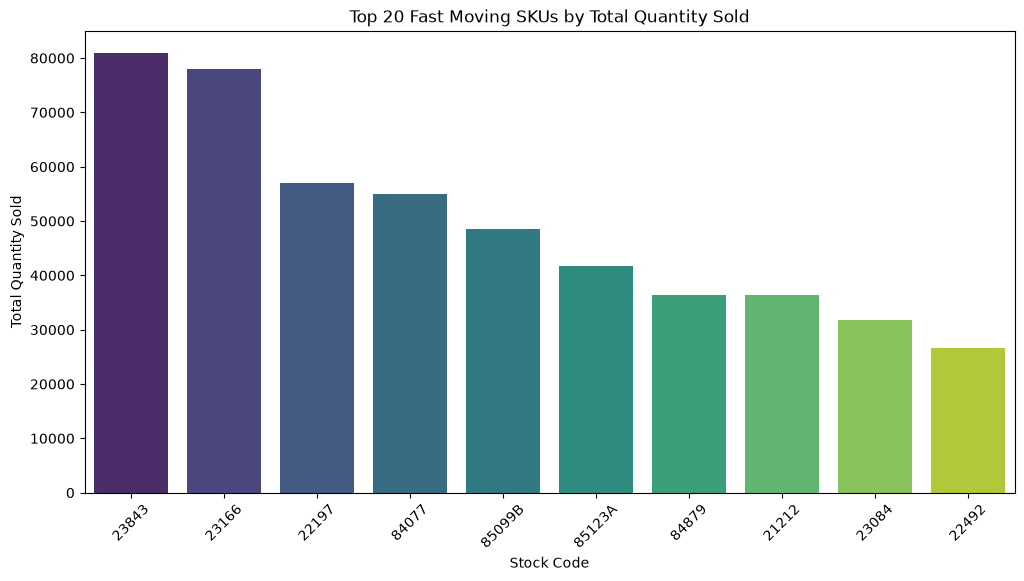

In [21]:
top_items = df_raw[df_raw['Quantity'] > 0].groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_items.index.astype(str), y=top_items.values,palette="viridis")

plt.title("Top 20 Fast Moving SKUs by Total Quantity Sold")
plt.xlabel("Stock Code")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [24]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   DateOnly     541909 non-null  object        
dtypes: datetime64[us](1), float64(2), int64(1), object(4), str(1)
memory usage: 37.2+ MB


In [23]:
df_raw.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [10]:
print("Missing values: " ,df.isnull().sum())

negative_quantities=df[df["Units_Sold"]<0]
print(f"Cancelled/ Returned transactions: {len(negative_quantities)}")

Missing values:  Date                 0
Region               0
Units_Sold           0
Current_Stock        0
Reorder_Triggered    0
dtype: int64
Cancelled/ Returned transactions: 0


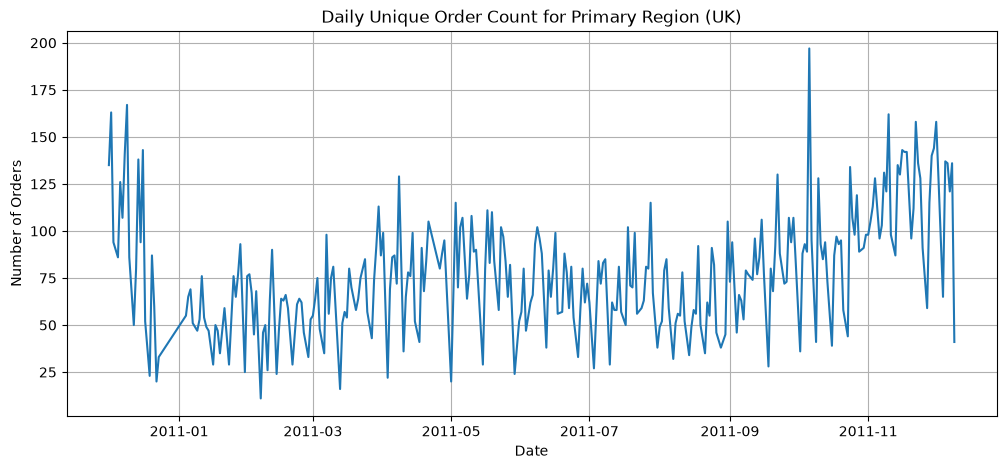

In [20]:
df_raw["InvoiceDate"]=pd.to_datetime(df_raw["InvoiceDate"])
df_raw["DateOnly"]= df_raw["InvoiceDate"].dt.date

uk_daily_orders=df_raw[df_raw["Country"]== "United Kingdom"].groupby("DateOnly")["InvoiceNo"].nunique()

plt.figure(figsize=(12,5))
uk_daily_orders.plot(kind="line")
plt.title("Daily Unique Order Count for Primary Region (UK)")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()

###### Invoice numbers starting with 'C' (negative quantities) represents 10,624 rows or roughly 1.96% of the total dataset. so this are returns.They will be filtered out before building the inventory drawdown simulation to avoid artificially inflate our stock levels

##### Macro Seasonality
###### The daily unique order count time-series confirms a massive spike in order velocity beginning in October and peaking in Novemver/ December . we must account for this seasonal phenomena

###### There are 135,080 missing values , however due to the goal of macro spatial demand forecasting ,we drop the customer ID column as it is not going to be that useful

##### Target Variable Selection
###### Stock code 23843 is the absolute highest-velocity SKU(over 80,000 Units sold).We Isolate the SKU to act as our baseline proxy for a fast-moving beverage product in the simulation